# Perch V2 — Zero-Shot vs Trained Classifier Evaluation

### Data format expected
- **WAV folder**: flat folder of `.wav` files named like `SCW1807_20200711_082500.wav`
- **Annotation JSON**: single JSON file mapping `SCW1807_20200711_082500-contours.json` → list of `{start, end, label}` dicts

### What this notebook does

1. Extracts **fixed 5s windows** and associates the corresponding labels
2. Embeds all windows with **Perch V2**
3. Evaluates **zero-shot** performance using Perch V2's built-in logits
4. Trains a **linear classifier** on top of the embeddings
5. Reports **per-class precision / recall / F1** for both, with plots
6. Performs **Dimensinality Reduction** to asses class separation in 2D and cluster formation.


> **Requirements**: GPU runtime + perch-hoplite installed (cells below)

In order to use Perch V2, you must install this version (or later) of TensorFlow and cuda

In [ ]:
%pip install tensorflow[and-cuda]~=2.20.0rc0

Choose the working gpu

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [2]:
import tensorflow as tf
import torch

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0], 'GPU')
    # Optional: prevent TF from grabbing all memory
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

2026-04-22 13:26:19.994366: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 13:26:20.047310: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-22 13:26:21.441857: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
#@title Imports
import json
import warnings
from pathlib import Path
import os
import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report,
    f1_score, precision_recall_fscore_support
)
import librosa.display
import soxr
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from perch_hoplite.zoo import model_configs

In [4]:
#@title Configuration { vertical-output: true }

#@markdown Folder containing all .wav files
wav_folder = '/data2/mromaniuc/cet-det/datasets/ADRIATIC_SEA/Audio_data'  #@param {type:'string'}

#@markdown Folder for base saving
save_dir = '/data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA'

#@markdown Path to your single annotation JSON file
annotation_json_path = '/data2/mromaniuc/cet-det/datasets/ADRIATIC_SEA/outputs/annotations.json'  #@param {type:'string'}

#@markdown Window size in seconds fed to Perch V2 (default 5.0)
window_size_s = 5.0  #@param {type:'number'}

#@markdown Minimum overlap (s) between an annotation and a window to label it as positive
min_overlap_s = 0.001  #@param {type:'number'}

#@markdown Fraction of data held out for testing
test_size = 0.3  #@param {type:'number'}

#@markdown Random seed
random_seed = 123  #@param {type:'number'}

In [5]:
#@title Load Perch V2 model
model_key = 'perch_v2'
embedding_model = model_configs.load_model_by_name(model_key)
sr = embedding_model.sample_rate

perch_class_names = list(embedding_model.class_list['labels'].classes)
print(f'Model loaded. Sample rate: {sr} Hz')
print(f'Perch V2 built-in classes: {len(perch_class_names)}')

I0000 00:00:1776857187.857283 1814167 gpu_device.cc:2020] Created device /device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9
I0000 00:00:1776857188.262465 1814167 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20749 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3b:00.0, compute capability: 8.9


Model loaded. Sample rate: 32000 Hz
Perch V2 built-in classes: 14795


# retrieving the data and performing zero-shot and fully-supervised classifications

In [7]:
X_clean =  np.load(f'{save_dir}/embeddings/X_embeddings.npy')   # (9209, 1536)
y_clean = np.load(f'{save_dir}/embeddings/y_labels.npy')   # (9209,)
Z_clean = np.load(f'{save_dir}/embeddings/Z_logits.npy')   # (9209,)

metadata_clean = pd.read_csv(f'{save_dir}/embeddings/metadata.csv')

print(f'Clean shapes — X: {X_clean.shape}, Z: {Z_clean.shape}, y: {y_clean.shape}')
print(f'Class distribution:')
print(pd.Series(y_clean).value_counts())

Clean shapes — X: (1180, 1536), Z: (1180, 14795), y: (1180,)
Class distribution:
click_only       702
background       238
click+whistle    194
whistle_only      46
Name: count, dtype: int64


In [23]:
#@title Temporal 10-fold cross-validation split (7/3 ratio)

n_folds = 10

le = LabelEncoder()
y_enc = le.fit_transform(y_clean)
class_names = list(le.classes_)
print('Classes:', class_names)

n = len(X_clean)
chunk_size = n // n_folds
chunks = [np.arange(i * chunk_size, (i + 1) * chunk_size) for i in range(n_folds)]
# absorb any remainder into the last chunk
chunks[-1] = np.arange((n_folds - 1) * chunk_size, n)

folds = []
for i in range(n_folds):
    test_chunks  = [chunks[(i + j) % n_folds] for j in range(3)]
    train_chunks = [chunks[(i + j) % n_folds] for j in range(3, n_folds)]
    test_idx  = np.concatenate(test_chunks)
    train_idx = np.concatenate(train_chunks)
    folds.append((train_idx, test_idx))

for i, (train_idx, test_idx) in enumerate(folds):
    print(f'Fold {i}: Train {len(train_idx)} (idx {train_idx[0]}–{train_idx[-1]}) | '
          f'Test {len(test_idx)} (idx {test_idx[0]}–{test_idx[-1]})')

Classes: ['background', 'click+whistle', 'click_only', 'whistle_only']
Fold 0: Train 826 (idx 354–1179) | Test 354 (idx 0–353)
Fold 1: Train 826 (idx 472–117) | Test 354 (idx 118–471)
Fold 2: Train 826 (idx 590–235) | Test 354 (idx 236–589)
Fold 3: Train 826 (idx 708–353) | Test 354 (idx 354–707)
Fold 4: Train 826 (idx 826–471) | Test 354 (idx 472–825)
Fold 5: Train 826 (idx 944–589) | Test 354 (idx 590–943)
Fold 6: Train 826 (idx 1062–707) | Test 354 (idx 708–1061)
Fold 7: Train 826 (idx 0–825) | Test 354 (idx 826–1179)
Fold 8: Train 826 (idx 118–943) | Test 354 (idx 944–117)
Fold 9: Train 826 (idx 236–1061) | Test 354 (idx 1062–235)


We have way to litte samples for the wistle_only class so the algorithms are breaking, not even class reweighting is helping in this case, so we will merge whistle_only and click+whistle -> whistle present

In [24]:
#@title Merge whistle classes + temporal 10-fold CV split (7/3 ratio)

# Remap whistle_only and click+whistle → whistle_present
label_remap = {
    'background': 'background',
    'click_only': 'click_only',
    'whistle_only': 'whistle_present',
    'click+whistle': 'whistle_present',
}
y_merged = np.array([label_remap[label] for label in y_clean])

le = LabelEncoder()
y_enc = le.fit_transform(y_merged)
class_names = list(le.classes_)
print('Classes:', class_names)
print('Distribution:', dict(zip(*np.unique(y_merged, return_counts=True))))

n = len(X_clean)
chunk_size = n // n_folds
chunks = [np.arange(i * chunk_size, (i + 1) * chunk_size) for i in range(n_folds)]
chunks[-1] = np.arange((n_folds - 1) * chunk_size, n)

folds = []
for i in range(n_folds):
    test_chunks  = [chunks[(i + j) % n_folds] for j in range(3)]
    train_chunks = [chunks[(i + j) % n_folds] for j in range(3, n_folds)]
    test_idx  = np.concatenate(test_chunks)
    train_idx = np.concatenate(train_chunks)
    folds.append((train_idx, test_idx))

for i, (train_idx, test_idx) in enumerate(folds):
    print(f'Fold {i}: Train {len(train_idx)} (idx {train_idx[0]}–{train_idx[-1]}) | '
          f'Test {len(test_idx)} (idx {test_idx[0]}–{test_idx[-1]}) | '
          f'Classes in test: {[class_names[c] for c in np.unique(y_enc[test_idx])]}')

Classes: ['background', 'click_only', 'whistle_present']
Distribution: {'background': 238, 'click_only': 702, 'whistle_present': 240}
Fold 0: Train 826 (idx 354–1179) | Test 354 (idx 0–353) | Classes in test: ['background', 'click_only', 'whistle_present']
Fold 1: Train 826 (idx 472–117) | Test 354 (idx 118–471) | Classes in test: ['background', 'click_only', 'whistle_present']
Fold 2: Train 826 (idx 590–235) | Test 354 (idx 236–589) | Classes in test: ['background', 'click_only', 'whistle_present']
Fold 3: Train 826 (idx 708–353) | Test 354 (idx 354–707) | Classes in test: ['background', 'click_only', 'whistle_present']
Fold 4: Train 826 (idx 826–471) | Test 354 (idx 472–825) | Classes in test: ['background', 'click_only', 'whistle_present']
Fold 5: Train 826 (idx 944–589) | Test 354 (idx 590–943) | Classes in test: ['background', 'click_only', 'whistle_present']
Fold 6: Train 826 (idx 1062–707) | Test 354 (idx 708–1061) | Classes in test: ['background', 'click_only', 'whistle_present

In [31]:
#@title Train classifiers + track metrics (3-class, 10-fold temporal CV)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
import time
import numpy as np

classifiers_factory = {
    'Logistic Regression': lambda: LogisticRegression(
        max_iter=1000, random_state=random_seed, class_weight='balanced'
    ),
    'Decision Tree': lambda: DecisionTreeClassifier(
        max_depth=10, random_state=random_seed, class_weight='balanced'
    ),
    'Random Forest': lambda: RandomForestClassifier(
        n_estimators=200, random_state=random_seed, class_weight='balanced', n_jobs=-1
    ),
    'SVM (RBF)': lambda: SVC(
        kernel='rbf', class_weight='balanced', random_state=random_seed, probability=True
    ),
}

cv_results = {name: defaultdict(list) for name in classifiers_factory}

for fold_idx, (train_idx, test_idx) in enumerate(folds):
    X_train, X_test = X_clean[train_idx], X_clean[test_idx]
    y_train, y_test = y_enc[train_idx], y_enc[test_idx]

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    print(f'\n{"="*80}')
    print(f'FOLD {fold_idx + 1}/{n_folds} — Train: {len(train_idx)} | Test: {len(test_idx)}')
    print(f'{"="*80}')

    for name, make_clf in classifiers_factory.items():
        clf = make_clf()
        t0 = time.time()

        clf.fit(X_train_sc, y_train)
        y_pred  = clf.predict(X_test_sc)
        y_proba = clf.predict_proba(X_test_sc)
        elapsed = time.time() - t0

        f1_macro     = f1_score(y_test, y_pred, average='macro', zero_division=0)
        f1_per_class = f1_score(y_test, y_pred, average=None,
                                labels=range(len(class_names)), zero_division=0)
        train_acc = clf.score(X_train_sc, y_train)
        test_acc  = clf.score(X_test_sc,  y_test)

        try:
            auc_ovr = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
        except ValueError:
            auc_ovr = float('nan')

        cv_results[name]['f1_macro'].append(f1_macro)
        cv_results[name]['f1_per_class'].append(f1_per_class)
        cv_results[name]['train_acc'].append(train_acc)
        cv_results[name]['test_acc'].append(test_acc)
        cv_results[name]['auc_ovr'].append(auc_ovr)
        cv_results[name]['time_s'].append(elapsed)
        cv_results[name]['y_proba'].append(y_proba)


        print(f'  {name:<20s} | F1: {f1_macro:.4f} | AUC: {auc_ovr:.4f} | '
              f'Train: {train_acc:.4f} | Test: {test_acc:.4f} | {elapsed:.1f}s')
        print(classification_report(y_test, y_pred,
                                    labels=list(range(len(class_names))),
                                    target_names=class_names, zero_division=0))

# ── Aggregate ────────────────────────────────────────────────────────────────
print('\n' + '=' * 100)
print(f'SUMMARY — 3-CLASS, {n_folds}-FOLD TEMPORAL CV')
print('=' * 100)
print(f'{"Classifier":<20} {"Macro F1":>12} {"AUC OVR":>12} {"Train":>8} {"Test":>8} {"Gap":>8} {"Time":>7}')
print('-' * 100)

for name in sorted(cv_results, key=lambda n: np.mean(cv_results[n]['f1_macro']), reverse=True):
    res = cv_results[name]
    f1_m, f1_s   = np.mean(res['f1_macro']), np.std(res['f1_macro'])
    auc_m, auc_s = np.nanmean(res['auc_ovr']), np.nanstd(res['auc_ovr'])
    tr_m  = np.mean(res['train_acc'])
    te_m  = np.mean(res['test_acc'])
    gap   = abs(tr_m - te_m)
    t_m   = np.mean(res['time_s'])
    print(f'{name:<20} {f1_m:>5.4f}±{f1_s:.4f} {auc_m:>5.4f}±{auc_s:.4f} '
          f'{tr_m:>8.4f} {te_m:>8.4f} {gap:>8.4f} {t_m:>6.1f}s')

print('\n' + '=' * 100)
print('PER-CLASS F1 (mean ± std across folds)')
print('=' * 100)
header = f'{"Classifier":<20}'
for cn in class_names:
    header += f' {cn:>22s}'
print(header)
print('-' * 100)

for name in sorted(cv_results, key=lambda n: np.mean(cv_results[n]['f1_macro']), reverse=True):
    f1_arr = np.array(cv_results[name]['f1_per_class'])
    row = f'{name:<20}'
    for c in range(len(class_names)):
        row += f' {np.mean(f1_arr[:, c]):>8.4f}±{np.std(f1_arr[:, c]):.4f}'
    print(row)


FOLD 1/10 — Train: 826 | Test: 354


  Logistic Regression  | F1: 0.7215 | AUC: 0.8625 | Train: 1.0000 | Test: 0.7232 | 0.3s
                 precision    recall  f1-score   support

     background       0.63      0.78      0.70        87
     click_only       0.82      0.66      0.73       188
whistle_present       0.67      0.81      0.74        79

       accuracy                           0.72       354
      macro avg       0.71      0.75      0.72       354
   weighted avg       0.74      0.72      0.72       354

  Decision Tree        | F1: 0.5809 | AUC: 0.6573 | Train: 0.9637 | Test: 0.6243 | 1.1s
                 precision    recall  f1-score   support

     background       0.61      0.36      0.45        87
     click_only       0.70      0.71      0.71       188
whistle_present       0.50      0.71      0.59        79

       accuracy                           0.62       354
      macro avg       0.60      0.59      0.58       354
   weighted avg       0.63      0.62      0.62       354

  Random Forest     

As a comparison, these are the results with the one random stratified split:
PER-CLASS F1 COMPARISON
Classifier                background      click_only whistle_present
SVM (RBF)                     0.6739          0.8224          0.6726
Logistic Regression           0.6144          0.8028          0.6667
Random Forest                 0.6099          0.8166          0.6239
Decision Tree                 0.6625          0.7544          0.6013

In [32]:
#@title PyTorch MLP with Dropout (3-class, 10-fold temporal CV)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score, roc_auc_score, accuracy_score
from collections import defaultdict
import numpy as np
import copy
import time

# ── Architecture definitions ──────────────────────────────────────────────────
torch_mlp_configs = {
    'PyTorch MLP (128) drop=0.4': {
        'hidden': (128,),
        'dropout': 0.4,
        'lr': 1e-4,
        'weight_decay': 1e-3,
        'epochs': 300,
        'patience': 30,
        'batch_size': 256,
    },
    'PyTorch MLP (64) drop=0.4': {
        'hidden': (64,),
        'dropout': 0.4,
        'lr': 1e-4,
        'weight_decay': 1e-3,
        'epochs': 300,
        'patience': 30,
        'batch_size': 256,
    },
}

n_classes = len(class_names)

def build_mlp(input_dim, hidden_sizes, dropout, n_classes):
    layers = []
    in_dim = input_dim
    for h in hidden_sizes:
        layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
        in_dim = h
    layers.append(nn.Linear(in_dim, n_classes))
    return nn.Sequential(*layers)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

mlp_cv_results = {name: defaultdict(list) for name in torch_mlp_configs}

for fold_idx, (train_idx, test_idx) in enumerate(folds):
    X_train, X_test = X_clean[train_idx], X_clean[test_idx]
    y_train, y_test = y_enc[train_idx],   y_enc[test_idx]

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    # Use last 15% of train fold as validation (temporal — no shuffle)
    val_size  = max(1, int(len(X_train_sc) * 0.15))
    X_tr      = X_train_sc[:-val_size]
    X_val     = X_train_sc[-val_size:]
    y_tr      = y_train[:-val_size]
    y_val     = y_train[-val_size:]

    class_counts  = np.bincount(y_tr, minlength=n_classes)
    class_weights = torch.tensor(
        [class_counts.sum() / (n_classes * max(c, 1)) for c in class_counts],
        dtype=torch.float32
    ).to(device)

    X_tr_t  = torch.tensor(X_tr,        dtype=torch.float32).to(device)
    y_tr_t  = torch.tensor(y_tr,        dtype=torch.long).to(device)
    X_val_t = torch.tensor(X_val,       dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val,       dtype=torch.long).to(device)
    X_te_t  = torch.tensor(X_test_sc,   dtype=torch.float32).to(device)

    print(f'\n{"="*80}')
    print(f'FOLD {fold_idx + 1}/{n_folds} — Train: {len(X_tr)} | Val: {len(X_val)} | Test: {len(X_test)}')
    print(f'{"="*80}')

    for name, cfg in torch_mlp_configs.items():
        loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                            batch_size=cfg['batch_size'], shuffle=True)

        model     = build_mlp(X_train_sc.shape[1], cfg['hidden'], cfg['dropout'], n_classes).to(device)
        optimizer = torch.optim.Adam(model.parameters(),
                                     lr=cfg['lr'], weight_decay=cfg['weight_decay'])
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        best_val_loss    = float('inf')
        patience_counter = 0
        best_state       = None
        best_epoch       = 0
        early_stopped    = False
        train_losses, val_losses = [], []
        train_accs,   val_accs   = [], []

        t0 = time.time()

        for epoch in range(1, cfg['epochs'] + 1):
            model.train()
            for xb, yb in loader:
                optimizer.zero_grad()
                criterion(model(xb), yb).backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                tr_logits  = model(X_tr_t)
                val_logits = model(X_val_t)
                tr_loss    = criterion(tr_logits,  y_tr_t).item()
                val_loss   = criterion(val_logits, y_val_t).item()
                tr_acc     = (tr_logits.argmax(1)  == y_tr_t).float().mean().item()
                val_acc    = (val_logits.argmax(1) == y_val_t).float().mean().item()

            train_losses.append(tr_loss)
            val_losses.append(val_loss)
            train_accs.append(tr_acc)
            val_accs.append(val_acc)

            if val_loss < best_val_loss:
                best_val_loss    = val_loss
                patience_counter = 0
                best_epoch       = epoch
                best_state       = copy.deepcopy(model.state_dict())
            else:
                patience_counter += 1
            if patience_counter >= cfg['patience']:
                early_stopped = True
                break

        model.load_state_dict(best_state)
        model.eval()
        with torch.no_grad():
            test_logits = model(X_te_t)
            test_proba  = torch.softmax(test_logits, dim=1).cpu().numpy()
            test_pred   = test_logits.argmax(1).cpu().numpy()

        elapsed      = time.time() - t0
        f1_macro     = f1_score(y_test, test_pred, average='macro', zero_division=0)
        f1_per_class = f1_score(y_test, test_pred, average=None,
                                labels=range(n_classes), zero_division=0)
        test_acc     = accuracy_score(y_test, test_pred)

        try:
            auc_ovr = roc_auc_score(y_test, test_proba, multi_class='ovr', average='weighted')
        except ValueError:
            auc_ovr = float('nan')

        mlp_cv_results[name]['f1_macro'].append(f1_macro)
        mlp_cv_results[name]['f1_per_class'].append(f1_per_class)
        mlp_cv_results[name]['train_acc'].append(train_accs[-1])
        mlp_cv_results[name]['test_acc'].append(test_acc)
        mlp_cv_results[name]['auc_ovr'].append(auc_ovr)
        mlp_cv_results[name]['time_s'].append(elapsed)
        mlp_cv_results[name]['best_epoch'].append(best_epoch)
        mlp_cv_results[name]['n_iter'].append(len(train_losses))
        mlp_cv_results[name]['train_losses'].append(train_losses)
        mlp_cv_results[name]['val_losses'].append(val_losses)
        mlp_cv_results[name]['train_accs'].append(train_accs)
        mlp_cv_results[name]['val_accs'].append(val_accs)
        mlp_cv_results[name]['y_proba'].append(test_proba)


        print(f'  {name} | Epochs: {len(train_losses)} (best: {best_epoch}) | '
              f'F1: {f1_macro:.4f} | AUC: {auc_ovr:.4f} | '
              f'Train: {train_accs[-1]:.4f} | Test: {test_acc:.4f} | {elapsed:.1f}s')
        print(classification_report(y_test, test_pred,
                                    labels=list(range(n_classes)),
                                    target_names=class_names, zero_division=0))

# ── Aggregate ─────────────────────────────────────────────────────────────────
print('\n' + '=' * 100)
print(f'PyTorch MLP SUMMARY — 3-class, {n_folds}-fold temporal CV')
print('=' * 100)
print(f'{"Model":<40} {"Macro F1":>12} {"AUC OVR":>12} {"Train":>8} '
      f'{"Test":>8} {"Gap":>8} {"Epochs":>8} {"Time":>8}')
print('-' * 100)

for name in sorted(mlp_cv_results, key=lambda n: np.mean(mlp_cv_results[n]['f1_macro']), reverse=True):
    res  = mlp_cv_results[name]
    f1_m, f1_s   = np.mean(res['f1_macro']), np.std(res['f1_macro'])
    auc_m, auc_s = np.nanmean(res['auc_ovr']), np.nanstd(res['auc_ovr'])
    tr_m  = np.mean(res['train_acc'])
    te_m  = np.mean(res['test_acc'])
    gap   = abs(tr_m - te_m)
    ep_m  = np.mean(res['best_epoch'])
    t_m   = np.mean(res['time_s'])
    print(f'{name:<40} {f1_m:>5.4f}±{f1_s:.4f} {auc_m:>5.4f}±{auc_s:.4f} '
          f'{tr_m:>8.4f} {te_m:>8.4f} {gap:>8.4f} {ep_m:>8.1f} {t_m:>8.1f}s')

print('\n' + '=' * 100)
print('PER-CLASS F1 (mean ± std across folds)')
print('=' * 100)
header = f'{"Model":<40}'
for cn in class_names:
    header += f' {cn:>22s}'
print(header)
print('-' * 100)

for name in sorted(mlp_cv_results, key=lambda n: np.mean(mlp_cv_results[n]['f1_macro']), reverse=True):
    f1_arr = np.array(mlp_cv_results[name]['f1_per_class'])
    row = f'{name:<40}'
    for c in range(n_classes):
        row += f' {np.mean(f1_arr[:, c]):>8.4f}±{np.std(f1_arr[:, c]):.4f}'
    print(row)

# Merge into overall results
if 'cv_results' in dir():
    cv_results.update(mlp_cv_results)
    print('\n✓ PyTorch MLP results merged into cv_results dict.')

Using device: cuda

FOLD 1/10 — Train: 703 | Val: 123 | Test: 354
  PyTorch MLP (128) drop=0.4 | Epochs: 94 (best: 64) | F1: 0.7656 | AUC: 0.8940 | Train: 0.9417 | Test: 0.7627 | 1.0s
                 precision    recall  f1-score   support

     background       0.61      0.95      0.75        87
     click_only       0.92      0.64      0.76       188
whistle_present       0.75      0.84      0.79        79

       accuracy                           0.76       354
      macro avg       0.76      0.81      0.77       354
   weighted avg       0.81      0.76      0.76       354

  PyTorch MLP (64) drop=0.4 | Epochs: 109 (best: 79) | F1: 0.7522 | AUC: 0.8899 | Train: 0.9388 | Test: 0.7514 | 1.5s
                 precision    recall  f1-score   support

     background       0.60      0.91      0.72        87
     click_only       0.92      0.64      0.76       188
whistle_present       0.73      0.84      0.78        79

       accuracy                           0.75       354
      mac

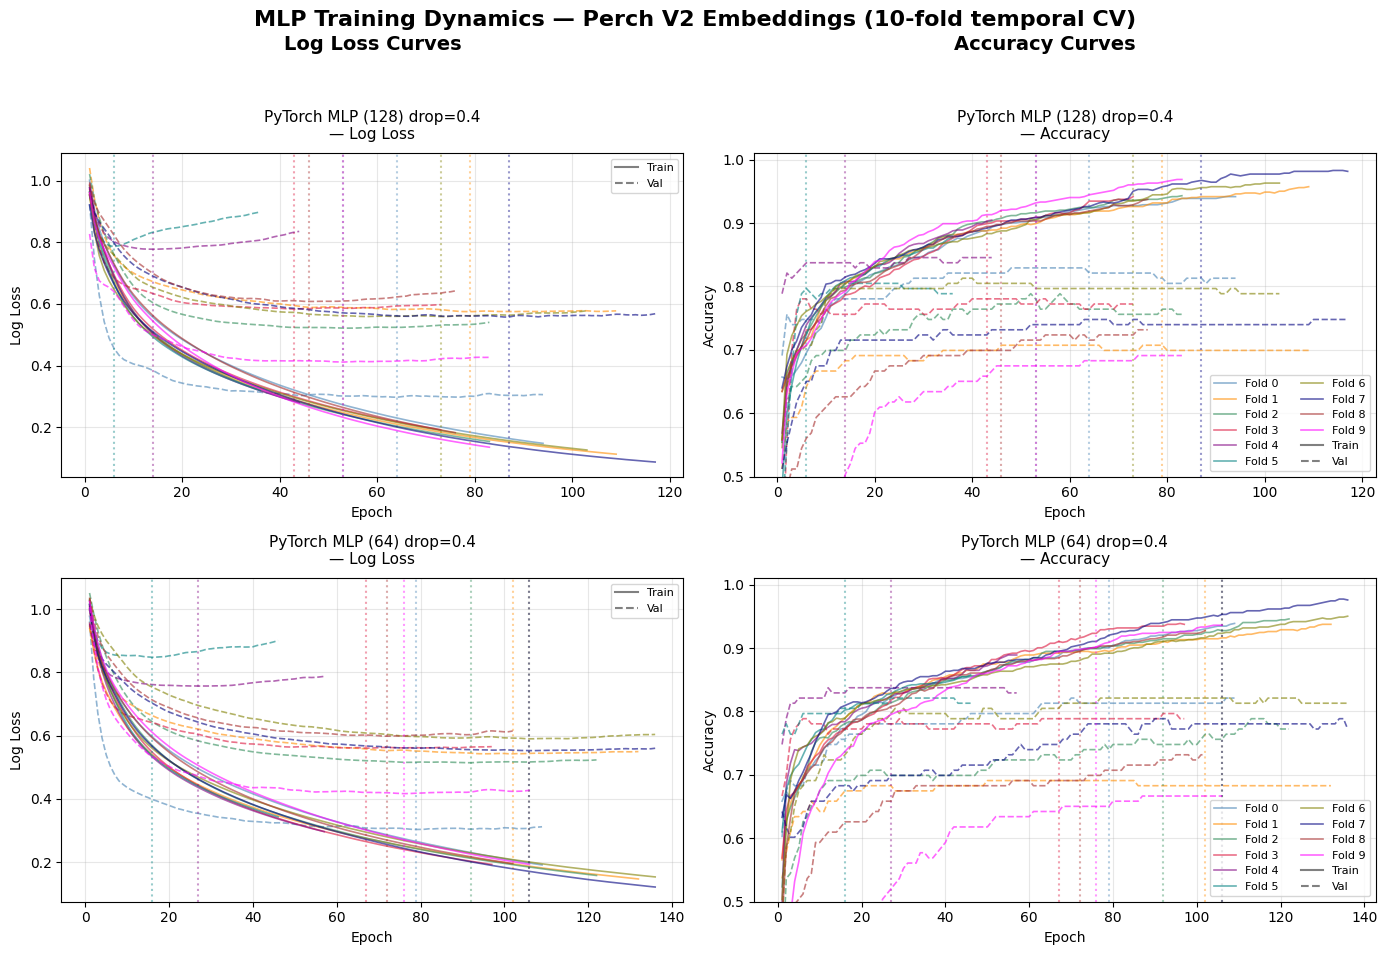

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

color_palette = ['steelblue', 'darkorange', 'seagreen', 'crimson', 'purple',
                 'teal', 'olive', 'navy', 'brown', 'magenta']

n_models = len(torch_mlp_configs)
n_folds  = len(folds)

fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
if n_models == 1:
    axes = axes[np.newaxis, :]

fig.suptitle('MLP Training Dynamics — Perch V2 Embeddings (10-fold temporal CV)',
             fontsize=16, fontweight='bold', y=0.98)

for idx, name in enumerate(torch_mlp_configs):
    fold_data = mlp_cv_results[name]
    ax_loss = axes[idx, 0]
    ax_acc  = axes[idx, 1]

    for fold_idx in range(n_folds):
        color   = color_palette[fold_idx % len(color_palette)]
        n_iter  = fold_data['n_iter'][fold_idx]
        epochs  = np.arange(1, n_iter + 1)
        best_ep = fold_data['best_epoch'][fold_idx]

        ax_loss.plot(epochs, fold_data['train_losses'][fold_idx],
                     color=color, linewidth=1.2, alpha=0.6)
        ax_loss.plot(epochs, fold_data['val_losses'][fold_idx],
                     color=color, linewidth=1.2, alpha=0.6, linestyle='--')
        ax_loss.axvline(best_ep, color=color, linestyle=':', alpha=0.4)

        ax_acc.plot(epochs, fold_data['train_accs'][fold_idx],
                    color=color, linewidth=1.2, alpha=0.6, label=f'Fold {fold_idx}')
        ax_acc.plot(epochs, fold_data['val_accs'][fold_idx],
                    color=color, linewidth=1.2, alpha=0.6, linestyle='--')
        ax_acc.axvline(best_ep, color=color, linestyle=':', alpha=0.4)

    ax_loss.set_title(f'{name}\n— Log Loss', fontsize=11, pad=10)
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Log Loss')
    ax_loss.grid(alpha=0.3)
    # manual legend: solid=train, dashed=val
    ax_loss.plot([], [], color='gray', linewidth=1.5, label='Train')
    ax_loss.plot([], [], color='gray', linewidth=1.5, linestyle='--', label='Val')
    ax_loss.legend(fontsize=8)

    ax_acc.set_title(f'{name}\n— Accuracy', fontsize=11, pad=10)
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.grid(alpha=0.3)
    ax_acc.set_ylim(0.5, 1.01)
    ax_acc.plot([], [], color='gray', linewidth=1.5, label='Train')
    ax_acc.plot([], [], color='gray', linewidth=1.5, linestyle='--', label='Val')
    ax_acc.legend(fontsize=8, ncol=2)

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
fig.text(0.27, 0.94, 'Log Loss Curves',  fontsize=14, fontweight='bold', ha='center')
fig.text(0.75, 0.94, 'Accuracy Curves',  fontsize=14, fontweight='bold', ha='center')

os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/mlp_4chart_diagnostics_time_dependent.png', dpi=150, bbox_inches='tight')
plt.show()

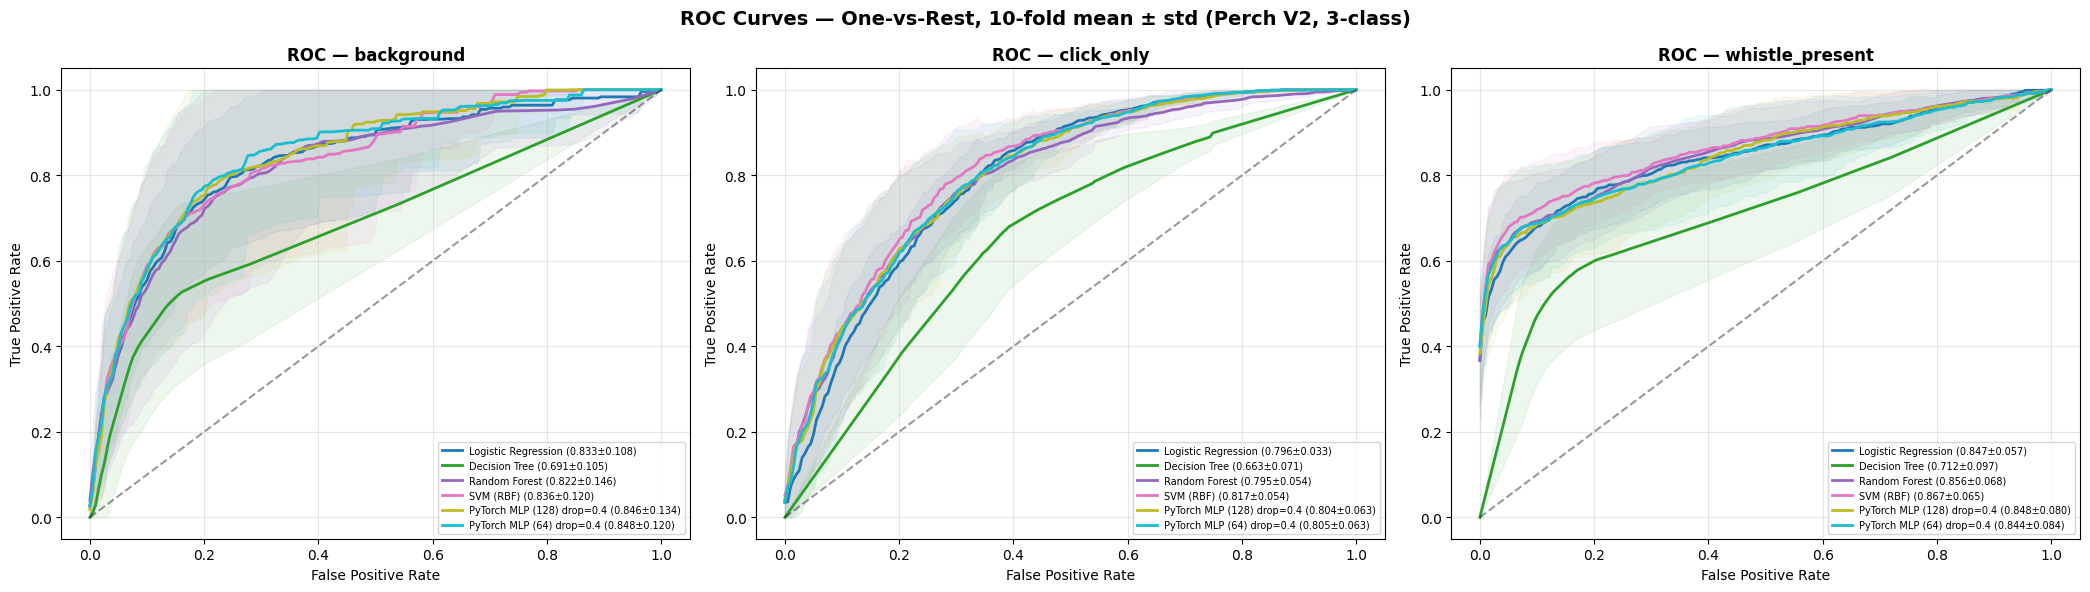

In [33]:
#@title ROC Curves — ALL Classifiers (3-class, one-vs-rest, 10-fold mean)
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

all_cv_results = {**cv_results, **mlp_cv_results}
colors = plt.cm.tab10(np.linspace(0, 1, len(all_cv_results)))

fig, axes = plt.subplots(1, len(class_names), figsize=(7 * len(class_names), 6))

for class_idx, (cn, ax) in enumerate(zip(class_names, axes)):
    for model_idx, (name, res) in enumerate(all_cv_results.items()):
        if 'y_proba' not in res or len(res['y_proba']) == 0:
            continue

        # Interpolate each fold's ROC onto a common FPR grid then average
        mean_fpr   = np.linspace(0, 1, 200)
        fold_tprs  = []
        fold_aucs  = []

        for fold_idx, (_, test_idx) in enumerate(folds):
            y_test_fold = y_enc[test_idx]
            proba_fold  = res['y_proba'][fold_idx]

            if proba_fold.ndim == 1 or proba_fold.shape[1] <= class_idx:
                continue

            y_bin = (y_test_fold == class_idx).astype(int)
            if y_bin.sum() == 0:
                continue

            fpr, tpr, _ = roc_curve(y_bin, proba_fold[:, class_idx])
            fold_tprs.append(np.interp(mean_fpr, fpr, tpr))
            fold_aucs.append(roc_auc_score(y_bin, proba_fold[:, class_idx]))

        if not fold_tprs:
            continue

        mean_tpr = np.mean(fold_tprs, axis=0)
        std_tpr  = np.std(fold_tprs,  axis=0)
        mean_auc = np.mean(fold_aucs)
        std_auc  = np.std(fold_aucs)

        color = colors[model_idx]
        ax.plot(mean_fpr, mean_tpr, color=color, linewidth=2,
                label=f'{name} ({mean_auc:.3f}±{std_auc:.3f})')
        ax.fill_between(mean_fpr,
                        np.clip(mean_tpr - std_tpr, 0, 1),
                        np.clip(mean_tpr + std_tpr, 0, 1),
                        color=color, alpha=0.08)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC — {cn}', fontsize=12, fontweight='bold')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — One-vs-Rest, 10-fold mean ± std (Perch V2, 3-class)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/roc_curves_3class_time_dependent.png', dpi=150, bbox_inches='tight')
plt.show()

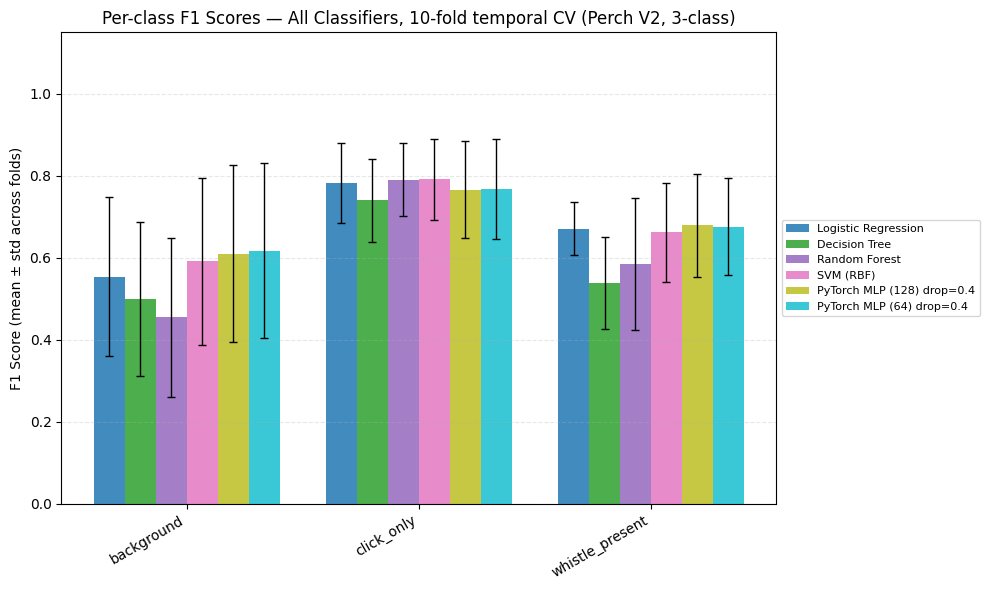

In [34]:
#@title Per-class F1 comparison bar chart — ALL classifiers (10-fold mean ± std)
import numpy as np
import matplotlib.pyplot as plt

all_cv_results = {**cv_results, **mlp_cv_results}

classifier_names = list(all_cv_results.keys())
n_classifiers    = len(classifier_names)
n_classes        = len(class_names)

colors = plt.cm.tab10(np.linspace(0, 1, min(n_classifiers, 10)))
x      = np.arange(n_classes)
width  = 0.8 / n_classifiers

fig, ax = plt.subplots(figsize=(max(10, n_classes * 2), 6))

for i, (name, res) in enumerate(all_cv_results.items()):
    f1_arr   = np.array(res['f1_per_class'])   # (n_folds, n_classes)
    f1_mean  = f1_arr.mean(axis=0)
    f1_std   = f1_arr.std(axis=0)
    offset   = (i - n_classifiers / 2 + 0.5) * width

    ax.bar(x + offset, f1_mean, width, label=name,
           color=colors[i % len(colors)], alpha=0.85)
    ax.errorbar(x + offset, f1_mean, yerr=f1_std,
                fmt='none', color='black', capsize=3, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=30, ha='right')
ax.set_ylabel('F1 Score (mean ± std across folds)')
ax.set_ylim(0, 1.15)
ax.set_title('Per-class F1 Scores — All Classifiers, 10-fold temporal CV (Perch V2, 3-class)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
os.makedirs(f'{save_dir}/figures', exist_ok=True)
plt.savefig(f'{save_dir}/figures/f1_comparison_all_classifiers.png', dpi=150, bbox_inches='tight')
plt.show()

In [38]:
for name, res in all_cv_results.items():
    print(f'{name}: y_pred folds stored = {len(res["y_pred"])}')

Logistic Regression: y_pred folds stored = 0
Decision Tree: y_pred folds stored = 0
Random Forest: y_pred folds stored = 0
SVM (RBF): y_pred folds stored = 0
PyTorch MLP (128) drop=0.4: y_pred folds stored = 0
PyTorch MLP (64) drop=0.4: y_pred folds stored = 0


In [37]:
#@title Save full results to CSV — ALL classifiers (10-fold temporal CV)
from sklearn.metrics import precision_recall_fscore_support
import pandas as pd
import numpy as np

all_cv_results = {**cv_results, **mlp_cv_results}

rows = []
for name, res in all_cv_results.items():
    f1_arr = np.array(res['f1_per_class'])  # (n_folds, n_classes)

    row = {
        'classifier':       name,
        'macro_f1_mean':    round(np.mean(res['f1_macro']), 4),
        'macro_f1_std':     round(np.std(res['f1_macro']),  4),
        'roc_auc_mean':     round(np.nanmean(res['auc_ovr']), 4),
        'roc_auc_std':      round(np.nanstd(res['auc_ovr']),  4),
        'train_acc_mean':   round(np.mean(res['train_acc']), 4),
        'test_acc_mean':    round(np.mean(res['test_acc']),  4),
        'time_s_mean':      round(np.mean(res['time_s']),    2),
    }

    for i, cls in enumerate(class_names):
        row[f'{cls}_f1_mean'] = round(np.mean(f1_arr[:, i]), 4)
        row[f'{cls}_f1_std']  = round(np.std(f1_arr[:, i]),  4)

    rows.append(row)

results_df = pd.DataFrame(rows).sort_values('macro_f1_mean', ascending=False)

os.makedirs(save_dir, exist_ok=True)
results_df.to_csv(f'{save_dir}/perch_v2_all_classifiers_results.csv', index=False)
print(f'Saved {len(results_df)} classifiers to {save_dir}/perch_v2_all_classifiers_results_time_dep.csv')
display(results_df.round(4))

Saved 6 classifiers to /data2/mromaniuc/cet-det/models/perch_v2/ADRIATIC_SEA/perch_v2_all_classifiers_results_time_dep.csv


,classifier,macro_f1_mean,macro_f1_std,roc_auc_mean,roc_auc_std,train_acc_mean,test_acc_mean,time_s_mean,background_f1_mean,background_f1_std,click_only_f1_mean,click_only_f1_std,whistle_present_f1_mean,whistle_present_f1_std
5,PyTorch MLP (64) drop=0.4,0.6872,0.0859,0.8199,0.0678,0.9296,0.7602,1.20,0.6173,0.2142,0.7682,0.1214,0.6762,0.1174
4,PyTorch MLP (128) drop=0.4,0.6851,0.0843,0.8205,0.0673,0.9417,0.7590,0.88,0.6100,0.2165,0.7665,0.1180,0.6789,0.1256
3,SVM (RBF),0.6817,0.0805,0.8299,0.0590,0.8981,0.7605,2.25,0.5915,0.2034,0.7916,0.0983,0.6621,0.1209
0,Logistic Regression,0.6688,0.0697,0.8162,0.0401,1.0000,0.7466,0.29,0.5531,0.1940,0.7822,0.0970,0.6711,0.0648
2,Random Forest,0.6098,0.0792,0.8134,0.0602,1.0000,0.7218,0.90,0.4543,0.1945,0.7905,0.0883,0.5844,0.1618
1,Decision Tree,0.5925,0.0896,0.6748,0.0718,0.9679,0.6763,1.09,0.4997,0.1883,0.7399,0.1008,0.5378,0.1116
